# 04 — Backtesting y Construcción de Cartera

**Objetivo:** convertir las predicciones out-of-sample del modelo XGBoost (notebook 03) en una estrategia de inversión cuantitativa, evaluando rigurosamente su rentabilidad y riesgo bajo costes de transacción realistas. La construcción de la cartera se aborda de forma incremental: partiendo de un baseline simple, se añaden palancas de portfolio construction una a una, midiendo el aporte cuantitativo de cada decisión.

---

### Alcance y delimitación

Este notebook se centra exclusivamente en la **construcción de cartera y backtesting**. El modelo predictivo está fijado y no se modifica. Las palancas evaluadas operan sobre la transformación *predicciones → pesos → P&L*, no sobre el modelo. Esta separación refleja la división estándar en *quant equity* entre **modelado** (notebook 03) y **portfolio construction** (este notebook).

### Metodología: ablación incremental

Cada estrategia se construye **acumulativamente** sobre la anterior. Esto permite cuantificar el aporte marginal de cada palanca y conecta con la metodología de ablación ya utilizada en el notebook 03.

| # | Estrategia | Palanca añadida | Pregunta que responde |
|---|---|---|---|
| 0 | Baseline | Deciles equal-weight (largo top 10%, corto bottom 10%) | Punto de partida del notebook 03 |
| 1 | Weighted ranking | Pesos continuos proporcionales al rank de la predicción | ¿Aprovechar el ordering completo mejora el Sharpe? |
| 2 | + Volatility scaling | Pesos divididos por volatilidad reciente (Garman-Klass) | ¿Igualar contribución al riesgo aporta? |
| 3 | + Beta-neutralización | Cartera con beta agregada al S&P 500 = 0 | ¿Eliminar exposición direccional residual estabiliza el Sharpe? |
| 4 | + EWMA smoothing | Suavizado temporal de predicciones (halflife = 2) | ¿Reducir turnover compensa la pérdida de información? |
| 5 | Ensemble | Combinación lineal Ridge + XGBoost sobre pipeline completo | ¿Promediar modelos aporta robustez? |

Las palancas no monotónicamente positivas (alguna podría empeorar el Sharpe) son un hallazgo legítimo y se reportan honestamente: la estrategia final se selecciona por evidencia empírica, no por orden de implementación.

### Decisiones técnicas

| Decisión | Valor | Justificación |
|---|---|---|
| **Notional** | Gross = 2 (dollar-neutral) | Estándar de hedge funds; \$1 en largos + \$1 en cortos. |
| **Frecuencia rebalanceo** | Diaria | Coherente con horizonte de predicción de 1 día. |
| **Costes** | 3 bps fijo + slippage proporcional a Amihud | Modelo simple y defendible. |
| **Universo** | 500+ activos del S&P 500 | Mismo del notebook 01-03. |
| **Período** | 2016–2024 (out-of-sample del notebook 03) | Resultados nunca vistos por el modelo. |

### Robustez estadística

La estrategia ganadora se somete a tres pruebas de robustez:

1. **Bootstrap** (10 000 muestras): intervalo de confianza del Sharpe.
2. **Permutation test** (1 000 muestras): p-value empírico del Sharpe vs aleatorización de predicciones.
3. **Estabilidad por sub-períodos**: comparación entre la primera y segunda mitad del período de test.

### Entradas y salidas

| Tipo | Archivo | Generado por |
|------|---------|--------------|
| Input  | `data/predictions_oos.parquet`        | notebook 03 |
| Input  | `data/feature_store.parquet`          | notebook 02 |
| Input  | `data/massive_financial_data.parquet` | notebook 01 |
| Input  | `data/model_training_metadata.json`   | notebook 03 |
| Output | `data/portfolio_returns_all.parquet`  | este notebook (consumido por dashboard) |
| Output | `data/portfolio_weights_final.parquet`| este notebook |
| Output | `data/backtest_metadata.json`         | este notebook |


## 1. Configuración del entorno

Inicializamos imports, rutas (resolución robusta consistente con notebooks anteriores), logging y constantes financieras.

**Constantes clave:**

- `TRADING_DAYS_YEAR = 252` — Días hábiles para anualización.
- `COMMISSION_BPS = 3` — Comisión fija por operación, en puntos básicos (0.03%).
- `SLIPPAGE_AMIHUD_COEF` — Coeficiente que escala el ratio de Amihud para producir slippage en bps. Se calibra empíricamente (búsqueda binaria) para que el slippage medio del universo, **tras aplicar el cap superior**, sea ≈ 3 bps. Calibrar por media en lugar de mediana es necesario porque la distribución del Amihud Ratio es fuertemente sesgada — la mediana es estable pero la media sin cap explota debido a outliers de activos iliquidos.
- `MAX_SLIPPAGE_BPS = 50` — Cota superior del slippage por operación. Refleja la realidad operativa: incluso en mid/small caps US, el slippage a horizonte diario raramente excede 50 bps por la presencia de market makers y liquidity providers (Frazzini, Israel & Moskowitz, 2018).
- `EWMA_HALFLIFE = 2` — Halflife del suavizado de predicciones, ajustable en sensibilidad.
- `BOOTSTRAP_N = 10_000`, `PERMUTATION_N = 1_000` — Número de muestras para tests de robustez.


In [1]:
import json
import logging
import warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

# Logging estructurado consistente con notebooks anteriores
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("backtesting")

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

In [2]:
# --- Resolución robusta de la raíz del proyecto ---
def _find_project_root(marker: str = "data", max_levels: int = 3) -> Path:
    """Localiza la raíz del proyecto buscando el directorio 'data/'."""
    here = Path.cwd()
    for candidate in [here, *list(here.parents)[:max_levels]]:
        if (candidate / marker).is_dir():
            return candidate
    raise FileNotFoundError(
        f"No se encontró el directorio '{marker}/' partiendo de {here}."
    )

PROJECT_ROOT = _find_project_root()
DATA_DIR     = PROJECT_ROOT / "data"

# --- Inputs ---
PREDICTIONS_FILE   = DATA_DIR / "predictions_oos.parquet"
FEATURE_STORE_FILE = DATA_DIR / "feature_store.parquet"
RAW_DATA_FILE      = DATA_DIR / "massive_financial_data.parquet"
MODEL_METADATA     = DATA_DIR / "model_training_metadata.json"

# --- Outputs ---
PORTFOLIO_RETURNS_FILE = DATA_DIR / "portfolio_returns_all.parquet"
PORTFOLIO_WEIGHTS_FILE = DATA_DIR / "portfolio_weights_final.parquet"
BACKTEST_METADATA_FILE = DATA_DIR / "backtest_metadata.json"

# Verificación temprana
for f in [PREDICTIONS_FILE, FEATURE_STORE_FILE, RAW_DATA_FILE]:
    if not f.exists():
        raise FileNotFoundError(f"No se encontró {f}. Ejecuta los notebooks previos.")

logger.info(f"PROJECT_ROOT     : {PROJECT_ROOT}")
logger.info(f"PREDICTIONS_FILE : {PREDICTIONS_FILE}")

17:23:16 | INFO     | PROJECT_ROOT     : c:\Users\Usuario\Desktop\bachelor-thesis
17:23:16 | INFO     | PREDICTIONS_FILE : c:\Users\Usuario\Desktop\bachelor-thesis\data\predictions_oos.parquet


In [22]:
# --- Constantes financieras ---
TRADING_DAYS_YEAR     = 252      # estándar para anualización
BENCHMARK             = "^GSPC"  # S&P 500 (notebook 01)

# --- Modelo de costes de transacción ---
COMMISSION_BPS        = 3.0      # comisión fija por operación (3 bps = 0.03%)
SLIPPAGE_AMIHUD_COEF  = 1e9      # coeficiente Amihud → bps; recalibrado en sección 10
MAX_SLIPPAGE_BPS      = 50.0     # cota superior del slippage por operación

# --- Hiperparámetros de las palancas ---
ROLLING_WINDOW_VOL    = 20       # ventana para volatility scaling y beta
EWMA_HALFLIFE         = 2        # suavizado temporal de predicciones

# --- Parámetros de robustez ---
BOOTSTRAP_N           = 10_000   # muestras para intervalo de confianza del Sharpe
PERMUTATION_N         = 300    # permutaciones para test de no-aleatoriedad

logger.info(f"Costes: {COMMISSION_BPS:.1f} bps + slippage(Amihud)")
logger.info(f"EWMA halflife: {EWMA_HALFLIFE}, ventana vol/beta: {ROLLING_WINDOW_VOL}")

18:07:12 | INFO     | Costes: 3.0 bps + slippage(Amihud)
18:07:12 | INFO     | EWMA halflife: 2, ventana vol/beta: 20


## 2. Carga de datos

Cargamos los cuatro inputs necesarios:

1. **Predicciones del modelo** (`predictions_oos.parquet`): panel `(Date, Ticker)` con `y_true` (retorno realizado) y `y_pred` (predicción de XGBoost).
2. **Feature store**: necesario para extraer `Garman_Klass_Vol` (volatility scaling) y `Amihud_Ratio` (slippage).
3. **Datos OHLCV crudos**: necesarios para los retornos del benchmark `^GSPC` (cálculo de betas) y como referencia.
4. **Metadata del modelo**: hiperparámetros y métricas del notebook 03 para trazabilidad.


In [4]:
# 1. Predicciones del modelo (output del notebook 03)
predictions = pd.read_parquet(PREDICTIONS_FILE)
logger.info(f"Predicciones cargadas: {predictions.shape}")

# 2. Feature store (para volatility scaling y slippage)
feature_store = pd.read_parquet(FEATURE_STORE_FILE)
logger.info(f"Feature store cargado: {feature_store.shape}")

# 3. Datos OHLCV crudos (para retornos del benchmark)
raw_ohlcv = pd.read_parquet(RAW_DATA_FILE)
logger.info(f"OHLCV crudo cargado: {raw_ohlcv.shape}")

# 4. Metadata del modelo
with open(MODEL_METADATA, "r", encoding="utf-8") as f:
    model_metadata = json.load(f)
logger.info(f"Modelo entrenado el: {model_metadata['training_timestamp_utc']}")

# Sanity checks
assert predictions.index.names == ["Date", "Ticker"], "Estructura del MultiIndex inesperada."
assert {"y_true", "y_pred"}.issubset(predictions.columns), "Faltan columnas en predicciones."
assert "Garman_Klass_Vol" in feature_store.columns, "Falta Garman_Klass_Vol en feature store."
assert "Amihud_Ratio"     in feature_store.columns, "Falta Amihud_Ratio en feature store."

# Información descriptiva
dates_test = predictions.index.get_level_values("Date").unique()
print(f"Período de backtest      : {dates_test.min().date()} → {dates_test.max().date()}")
print(f"Días totales             : {len(dates_test):,}")
print(f"Tickers únicos           : {predictions.index.get_level_values('Ticker').nunique()}")
print(f"Filas de predicción      : {len(predictions):,}")

17:23:32 | INFO     | Predicciones cargadas: (1103511, 3)
17:23:32 | INFO     | Feature store cargado: (2402184, 17)
17:23:33 | INFO     | OHLCV crudo cargado: (5295, 2525)
17:23:33 | INFO     | Modelo entrenado el: 2026-05-05T08:43:42.810690+00:00


Período de backtest      : 2016-01-04 → 2024-12-31
Días totales             : 2,269
Tickers únicos           : 501
Filas de predicción      : 1,103,511


### 2.1 Generación de predicciones del baseline Ridge

Para evaluar la estrategia 5 (ensemble Ridge + XGBoost), necesitamos las predicciones de Ridge sobre los mismos folds out-of-sample. Como el notebook 03 no las persistía, las regeneramos aquí — el cómputo es trivial (~5 segundos) y mantiene una arquitectura limpia donde el notebook 03 produce solo el modelo principal.

Replicamos exactamente la metodología del notebook 03: target demeaned para entrenamiento, evaluación contra retorno real, mismos folds walk-forward.


In [5]:
# Reconstruir folds idénticos al notebook 03
TRAIN_START_YEAR = 2005
FIRST_VAL_YEAR   = 2015
LAST_VAL_YEAR    = 2023
PURGE_DAYS       = 5

unique_dates = pd.DatetimeIndex(sorted(set(feature_store.index.get_level_values("Date"))))


def _generate_folds_for_ridge() -> list[dict]:
    """Reconstruye los folds del notebook 03 para regenerar Ridge."""
    folds = []
    sorted_dates = unique_dates
    for i, val_year in enumerate(range(FIRST_VAL_YEAR, LAST_VAL_YEAR + 1), start=1):
        val_dates  = sorted_dates[(sorted_dates >= pd.Timestamp(f"{val_year}-01-01")) &
                                   (sorted_dates <= pd.Timestamp(f"{val_year}-12-31"))]
        test_dates = sorted_dates[(sorted_dates >= pd.Timestamp(f"{val_year+1}-01-01")) &
                                   (sorted_dates <= pd.Timestamp(f"{val_year+1}-12-31"))]
        if len(val_dates) == 0 or len(test_dates) == 0:
            continue
        train_end_idx = sorted_dates.get_indexer([val_dates[0]])[0] - PURGE_DAYS - 1
        if train_end_idx <= 0:
            continue
        folds.append({
            "fold":        i,
            "train_start": pd.Timestamp(f"{TRAIN_START_YEAR}-01-01"),
            "train_end":   sorted_dates[train_end_idx],
            "test_start":  test_dates[0],
            "test_end":    test_dates[-1],
        })
    return folds


# Preparar matrices alineadas con el feature store
target_col   = "Target_FwdRet_1D"
feature_cols = [c for c in feature_store.columns if not c.startswith("Target")]
X_full     = feature_store[feature_cols]
y_raw_full = feature_store[target_col]
y_full     = y_raw_full.groupby(level="Date").transform(lambda s: s - s.mean())

# Walk-forward Ridge
ridge_preds_list = []
for fold in _generate_folds_for_ridge():
    dates = X_full.index.get_level_values("Date")
    train_mask = (dates >= fold["train_start"]) & (dates <= fold["train_end"])
    test_mask  = (dates >= fold["test_start"])  & (dates <= fold["test_end"])

    scaler = StandardScaler().fit(X_full[train_mask])
    model  = Ridge(alpha=1.0, random_state=SEED)
    model.fit(scaler.transform(X_full[train_mask]), y_full[train_mask])
    pred_test = model.predict(scaler.transform(X_full[test_mask]))

    ridge_preds_list.append(pd.DataFrame({
        "y_pred_ridge": pred_test
    }, index=X_full[test_mask].index))

ridge_preds = pd.concat(ridge_preds_list)
logger.info(f"Predicciones Ridge regeneradas: {ridge_preds.shape}")

# Unir con las predicciones de XGBoost
predictions = predictions.join(ridge_preds, how="inner")
predictions = predictions.rename(columns={"y_pred": "y_pred_xgb"})
logger.info(f"Panel final de predicciones: {predictions.shape}")
print(predictions.head())

17:23:48 | INFO     | Predicciones Ridge regeneradas: (1103511, 1)
17:23:48 | INFO     | Panel final de predicciones: (1103511, 4)


                     y_true  y_pred_xgb  fold  y_pred_ridge
Date       Ticker                                          
2016-01-04 CFG    -0.004651    0.000005     1      0.000053
           MDLZ    0.008221   -0.000087     1     -0.000141
           CMS     0.007863    0.000060     1      0.000164
           RVTY    0.011062    0.000189     1      0.000056
           GLW    -0.000558   -0.000211     1     -0.000357


## 3. Framework de backtesting

Diseñamos el motor de backtesting siguiendo principios de **separación de responsabilidades**:

- Una **estrategia** es una función que produce un panel de pesos `(Date, Ticker) → weight`.
- El **motor de backtest** aplica esos pesos a los retornos realizados y produce métricas.
- Los **costes de transacción** se aplican como una capa separable.

Esta arquitectura permite probar estrategias diferentes con el mismo motor, garantizando comparabilidad.

### 3.1 Convenciones de pesos

Para una cartera *long-short* dollar-neutral con notional gross = 2:

$$
\sum_{i: w_i > 0} w_i = 1, \quad \sum_{i: w_i < 0} w_i = -1, \quad \sum_i |w_i| = 2
$$

El retorno diario de la cartera es:

$$
R_t = \sum_i w_{i,t} \cdot r_{i,t+1}
$$

donde $r_{i,t+1}$ es el retorno realizado del activo $i$ entre $t$ y $t+1$ (es decir, `y_true` en nuestras predicciones).

### 3.2 Modelo de costes

Los costes de la operación de un activo $i$ en el día $t$ son:

$$
\text{coste}_{i,t} = \Bigl(c_{\text{fix}} + \min\bigl(\alpha \cdot \text{Amihud}_{i,t},\ s_{\max}\bigr)\Bigr) \cdot |w_{i,t} - w_{i,t-1}|
$$

donde:

- $c_{\text{fix}} = 3$ bps es la comisión fija de broker.
- $\alpha \cdot \text{Amihud}_{i,t}$ es el slippage proporcional al ratio de iliquidez.
- $s_{\max} = 50$ bps es la **cota superior del slippage por operación**.
- $|w_{i,t} - w_{i,t-1}|$ es el cambio absoluto en el peso (turnover de la posición).

#### Por qué se acota el slippage

El Amihud Ratio es un proxy de iliquidez con distribución fuertemente sesgada: la cola superior contiene días/activos donde el indicador alcanza valores extremos (volúmenes muy bajos o eventos atípicos) que, sin acotar, producirían slippages físicamente imposibles (millones de bps por operación). En la realidad operativa, los costes de ejecución a horizonte diario en US equities están limitados por la presencia de market makers y *liquidity providers*, raramente excediendo 50 bps incluso en mid/small caps menos líquidas (Frazzini, Israel & Moskowitz, *Trading Costs of Asset Pricing Anomalies*, 2018).

El coeficiente $\alpha$ se calibra empíricamente en la **sección 10** mediante búsqueda binaria, de forma que el slippage **medio** del universo (tras aplicar el cap) sea ≈ 3 bps. Calibrar por media y no por mediana es necesario para que las métricas agregadas (suma de costes diarios) reflejen un coste realista, dado que la distribución del Amihud es lognormal-like.


In [6]:
def normalize_dollar_neutral(weights: pd.Series) -> pd.Series:
    """
    Normaliza pesos a notional gross = 2 (dollar-neutral).

    Para cada fecha: largos suman +1, cortos suman -1.
    Si todos los pesos de un día tienen el mismo signo, se normaliza por su suma absoluta.

    Parameters
    ----------
    weights : pd.Series con MultiIndex (Date, Ticker)

    Returns
    -------
    pd.Series con la misma estructura, pesos normalizados.
    """
    def _normalize_day(w: pd.Series) -> pd.Series:
        long_sum  = w[w > 0].sum()
        short_sum = -w[w < 0].sum()  # positivo
        out = w.copy()
        if long_sum > 0:
            out[w > 0] = w[w > 0] / long_sum
        if short_sum > 0:
            out[w < 0] = w[w < 0] / short_sum
        return out

    return weights.groupby(level="Date").transform(_normalize_day)


def compute_portfolio_returns(weights: pd.Series, realized_returns: pd.Series) -> pd.Series:
    """
    Aplica pesos a retornos realizados para obtener retorno diario del portfolio.

    El peso w_t se aplica al retorno r_{t+1} → al ser y_true ya el retorno forward,
    el cálculo es directo: R_t = sum_i w_{i,t} * y_true_{i,t}.
    """
    df = pd.DataFrame({"w": weights, "r": realized_returns}).dropna()
    return df.groupby(level="Date").apply(lambda g: (g["w"] * g["r"]).sum())


def compute_turnover(weights: pd.Series) -> pd.Series:
    """
    Calcula turnover diario = sum_i |w_{i,t} - w_{i,t-1}|.

    El turnover representa el volumen total operado en cada día.
    Para una cartera dollar-neutral con notional gross = 2, el turnover máximo
    teórico es 4 (rotación completa de todas las posiciones).
    """
    weights_wide = weights.unstack(level="Ticker").fillna(0.0)
    diff = weights_wide.diff().abs().sum(axis=1)
    return diff.rename("turnover")


def compute_costs(weights: pd.Series, amihud: pd.Series,
                  commission_bps: float = COMMISSION_BPS,
                  amihud_coef: float = SLIPPAGE_AMIHUD_COEF,
                  max_slippage_bps: float = MAX_SLIPPAGE_BPS) -> pd.Series:
    """
    Calcula los costes de transacción por día.

    coste_diario = sum_i (c_fix + min(alpha * Amihud_i, max_slip)) * |delta w_i|

    El cap superior del slippage (max_slippage_bps) refleja la realidad
    operativa: incluso en activos iliquidos, el slippage de ejecución
    a horizonte diario está limitado por market makers y liquidity providers
    (Frazzini, Israel & Moskowitz, 2018). Sin este cap, los outliers extremos
    de la distribución del Amihud Ratio producirían costes físicamente
    imposibles que dominarían el cálculo agregado.

    Returns
    -------
    pd.Series con coste diario en unidades de retorno (no en bps).
    """
    weights_wide = weights.unstack(level="Ticker").fillna(0.0)
    delta_w = weights_wide.diff().abs()

    # Slippage por activo y día, ACOTADO superiormente
    amihud_wide = amihud.unstack(level="Ticker").reindex_like(weights_wide).fillna(0.0)
    slippage_bps = (amihud_coef * amihud_wide).clip(upper=max_slippage_bps)

    # Coste total = (commission + slippage) * |delta w|
    cost_per_trade_bps = commission_bps + slippage_bps
    daily_cost_bps = (cost_per_trade_bps * delta_w).sum(axis=1)

    return (daily_cost_bps / 10_000.0).rename("daily_cost")


def compute_metrics(returns: pd.Series, costs: pd.Series | None = None,
                    label: str = "") -> dict:
    """
    Calcula métricas estándar de portfolio.

    Si se proporcionan costes, los aplica ANTES de calcular las métricas
    (Sharpe neto, retorno neto).
    """
    if costs is not None:
        net_returns = returns.sub(costs, fill_value=0.0)
    else:
        net_returns = returns

    if net_returns.std() == 0 or len(net_returns) < 30:
        return {"label": label, "n_days": len(net_returns)}

    ann_return = net_returns.mean() * TRADING_DAYS_YEAR
    ann_vol    = net_returns.std()  * np.sqrt(TRADING_DAYS_YEAR)
    sharpe     = ann_return / ann_vol if ann_vol > 0 else 0.0

    # Sortino: usa downside deviation
    downside     = net_returns[net_returns < 0]
    downside_vol = downside.std() * np.sqrt(TRADING_DAYS_YEAR) if len(downside) > 0 else 0.0
    sortino      = ann_return / downside_vol if downside_vol > 0 else 0.0

    # Drawdown
    cumulative = (1 + net_returns).cumprod()
    drawdown   = (cumulative / cumulative.cummax() - 1).min()

    # t-stat del retorno medio diario
    t_stat = net_returns.mean() / (net_returns.std() / np.sqrt(len(net_returns)))

    return {
        "label":             label,
        "ann_return":        float(ann_return),
        "ann_vol":           float(ann_vol),
        "sharpe":            float(sharpe),
        "sortino":           float(sortino),
        "max_drawdown":      float(drawdown),
        "cum_return":        float(cumulative.iloc[-1] - 1),
        "t_stat":            float(t_stat),
        "n_days":            int(len(net_returns)),
    }


logger.info("Framework de backtesting definido.")

17:23:56 | INFO     | Framework de backtesting definido.


## 4. Estrategia 0 — Baseline: deciles equal-weight

Replicamos la estrategia del notebook anterior como punto de partida:

1. Cada día, ordenar los activos por la predicción del modelo.
2. **Long**: top decil (10% con predicción más alta), pesos iguales.
3. **Short**: bottom decil (10% con predicción más baja), pesos iguales.
4. Notional gross = 2 (largos suman +1, cortos suman −1).

Es la estrategia más simple posible y servirá como referencia para medir el aporte de las palancas siguientes.


In [7]:
def strategy_decile_equal_weight(predictions_df: pd.DataFrame,
                                  pred_col: str = "y_pred_xgb",
                                  n_quantiles: int = 10) -> pd.Series:
    """
    Genera pesos para la estrategia baseline: long top decil, short bottom decil,
    pesos iguales dentro de cada lado.

    Returns
    -------
    pd.Series con MultiIndex (Date, Ticker) y pesos en (-w, 0, +w).
    """
    df = predictions_df[[pred_col]].copy()
    df["quantile"] = (
        df.groupby(level="Date")[pred_col]
          .transform(lambda x: pd.qcut(x, n_quantiles, labels=False, duplicates="drop"))
    )

    weights = pd.Series(0.0, index=df.index)
    weights[df["quantile"] == n_quantiles - 1] = 1.0    # long top decil
    weights[df["quantile"] == 0]                = -1.0  # short bottom decil

    return normalize_dollar_neutral(weights)


# Generar pesos y backtest
weights_s0 = strategy_decile_equal_weight(predictions)
returns_s0 = compute_portfolio_returns(weights_s0, predictions["y_true"])
turnover_s0 = compute_turnover(weights_s0)

# Métricas brutas (sin costes todavía)
metrics_s0 = compute_metrics(returns_s0, label="S0_Baseline")
metrics_s0["avg_turnover"] = float(turnover_s0.mean())

print("--- Estrategia 0: Baseline (deciles equal-weight, sin costes) ---")
for k, v in metrics_s0.items():
    if isinstance(v, float):
        print(f"  {k:20s}: {v:.4f}")
    else:
        print(f"  {k:20s}: {v}")

--- Estrategia 0: Baseline (deciles equal-weight, sin costes) ---
  label               : S0_Baseline
  ann_return          : 0.2032
  ann_vol             : 0.2029
  sharpe              : 1.0013
  sortino             : 1.2961
  max_drawdown        : -0.4197
  cum_return          : 4.1711
  t_stat              : 3.0045
  n_days              : 2269
  avg_turnover        : 1.7781


## 5. Estrategia 1 — Weighted ranking continuo

**Palanca añadida:** sustituir los deciles discretos por pesos continuos proporcionales al rank.

Cada activo recibe un peso proporcional a su posición en el ordering del día:

$$
w_{i,t} = 2 \cdot (\text{rank}_{i,t}^{\text{pct}} - 0.5)
$$

donde $\text{rank}^{\text{pct}} \in [0,1]$ es el percentil de la predicción ese día. Esto da:

- $w = +1$ al activo con la mayor predicción.
- $w = -1$ al activo con la menor predicción.
- $w \approx 0$ a los activos del centro del ranking.

**Por qué funciona:** la información del ordering completo del modelo se aprovecha, no solo los extremos. Un activo en el percentil 90 contribuye más que uno en el 70, en lugar de ambos pesar lo mismo (deciles) o uno pesar y otro no (top decil binario).

Tras generar los pesos crudos, los normalizamos a notional gross = 2.


In [8]:
def strategy_weighted_ranking(predictions_df: pd.DataFrame,
                              pred_col: str = "y_pred_xgb") -> pd.Series:
    """
    Pesos continuos proporcionales al rank cross-sectional de la predicción.
    """
    df = predictions_df[[pred_col]].copy()
    rank_pct = (
        df.groupby(level="Date")[pred_col]
          .transform(lambda x: x.rank(pct=True))
    )
    raw_weights = 2.0 * (rank_pct - 0.5)  # [-1, +1]
    return normalize_dollar_neutral(raw_weights)


weights_s1  = strategy_weighted_ranking(predictions)
returns_s1  = compute_portfolio_returns(weights_s1, predictions["y_true"])
turnover_s1 = compute_turnover(weights_s1)

metrics_s1 = compute_metrics(returns_s1, label="S1_WeightedRanking")
metrics_s1["avg_turnover"] = float(turnover_s1.mean())

print("--- Estrategia 1: Weighted ranking (sin costes) ---")
for k, v in metrics_s1.items():
    if isinstance(v, float):
        print(f"  {k:20s}: {v:.4f}")
    else:
        print(f"  {k:20s}: {v}")

# Comparación incremental
delta_sharpe = metrics_s1["sharpe"] - metrics_s0["sharpe"]
print(f"\nΔ Sharpe vs Baseline: {delta_sharpe:+.4f}")

--- Estrategia 1: Weighted ranking (sin costes) ---
  label               : S1_WeightedRanking
  ann_return          : 0.1204
  ann_vol             : 0.1200
  sharpe              : 1.0031
  sortino             : 1.2771
  max_drawdown        : -0.2706
  cum_return          : 1.7705
  t_stat              : 3.0099
  n_days              : 2269
  avg_turnover        : 1.2796

Δ Sharpe vs Baseline: +0.0018


## 6. Estrategia 2 — Weighted ranking + Volatility scaling

**Palanca añadida:** dividir cada peso por la volatilidad reciente del activo.

$$
w'_{i,t} = \frac{w_{i,t}}{\sigma_{i,t}}
$$

donde $\sigma_{i,t}$ es la volatilidad Garman-Klass anualizada (calculada en el notebook 02 sobre ventana de 20 días).

**Por qué funciona:** sin escalado, dos activos con la misma señal contribuyen igual al portfolio, pero si uno tiene volatilidad doble que el otro, también contribuye con el doble de varianza. Dividir por la volatilidad **iguala la contribución al riesgo** de cada posición — es el principio de *risk parity* aplicado a nivel de activo individual.

Tras escalar, re-normalizamos a notional gross = 2.


In [9]:
def strategy_weighted_ranking_vol_scaled(predictions_df: pd.DataFrame,
                                          feature_store: pd.DataFrame,
                                          pred_col: str = "y_pred_xgb") -> pd.Series:
    """
    Pesos del ranking continuo divididos por volatilidad Garman-Klass.
    """
    raw_weights = strategy_weighted_ranking(predictions_df, pred_col)
    vol = feature_store["Garman_Klass_Vol"].reindex(raw_weights.index)

    # Evitar división por cero o NaN
    vol = vol.fillna(vol.median()).clip(lower=1e-4)

    scaled = raw_weights / vol
    return normalize_dollar_neutral(scaled)


weights_s2  = strategy_weighted_ranking_vol_scaled(predictions, feature_store)
returns_s2  = compute_portfolio_returns(weights_s2, predictions["y_true"])
turnover_s2 = compute_turnover(weights_s2)

metrics_s2 = compute_metrics(returns_s2, label="S2_VolScaled")
metrics_s2["avg_turnover"] = float(turnover_s2.mean())

print("--- Estrategia 2: + Volatility scaling (sin costes) ---")
for k, v in metrics_s2.items():
    if isinstance(v, float):
        print(f"  {k:20s}: {v:.4f}")
    else:
        print(f"  {k:20s}: {v}")

delta_sharpe = metrics_s2["sharpe"] - metrics_s1["sharpe"]
print(f"\nΔ Sharpe vs Estrategia 1: {delta_sharpe:+.4f}")

--- Estrategia 2: + Volatility scaling (sin costes) ---
  label               : S2_VolScaled
  ann_return          : 0.2662
  ann_vol             : 0.2175
  sharpe              : 1.2237
  sortino             : 1.7083
  max_drawdown        : -0.2673
  cum_return          : 7.9226
  t_stat              : 3.6720
  n_days              : 2269
  avg_turnover        : 1.3304

Δ Sharpe vs Estrategia 1: +0.2206


## 7. Estrategia 3 — + Beta-neutralización

**Palanca añadida:** ajustar los pesos para que la beta agregada del portfolio respecto al S&P 500 sea cero.

### 7.1 Formulación

Para cada activo $i$ en la fecha $t$, calculamos su beta rolling al S&P 500:

$$
\beta_{i,t} = \frac{\text{Cov}(r_i, r_m)_{t,20}}{\text{Var}(r_m)_{t,20}}
$$

La beta agregada del portfolio es:

$$
\beta_{P,t} = \sum_i w_{i,t} \cdot \beta_{i,t}
$$

Para forzar $\beta_{P,t} = 0$, ajustamos los pesos restando una posición proporcional a la beta:

$$
w'_{i,t} = w_{i,t} - \frac{\beta_{i,t}}{\sum_j \beta_{j,t}^2} \cdot \beta_{P,t}
$$

Esta es la proyección ortogonal de los pesos al espacio de pesos beta-neutrales (proyección de mínima distorsión que cumple la restricción).

### 7.2 Por qué funciona

Una cartera *long-short* con pesos heurísticos puede tener una beta agregada distinta de cero por puro azar — por ejemplo, si los activos del top decil tienden a ser de alta beta (sectores cíclicos) y los del bottom decil de baja beta (defensivos). En ese caso, parte de la rentabilidad de la cartera viene de **exposición direccional al mercado**, no de la señal del modelo. La beta-neutralización elimina ese componente.

Si la cartera sin neutralizar ya tiene beta ≈ 0 (porque las predicciones son simétricas respecto a beta), el ajuste será pequeño. Si tiene beta importante, la neutralización debería **reducir varianza** sin afectar significativamente al retorno, mejorando el Sharpe.


In [10]:
# Calcular betas rolling al benchmark
def compute_rolling_betas(raw_ohlcv: pd.DataFrame,
                          benchmark: str = BENCHMARK,
                          window: int = ROLLING_WINDOW_VOL) -> pd.DataFrame:
    """
    Calcula la beta rolling de cada activo al benchmark, replicando la lógica
    del notebook 02 (vol idiosincrásica).

    Returns
    -------
    pd.DataFrame con MultiIndex (Date, Ticker), columna 'beta'.
    """
    close = raw_ohlcv.xs("Close", axis=1, level=1)
    returns = close.pct_change()
    bench_returns = returns[benchmark]

    var_market = bench_returns.rolling(window).var()
    cov_assets = returns.rolling(window).cov(bench_returns)
    rolling_beta = cov_assets.div(var_market + 1e-12, axis=0)

    # Stack a formato panel
    beta_panel = rolling_beta.stack(future_stack=True).to_frame("beta")
    beta_panel.index.names = ["Date", "Ticker"]
    return beta_panel


logger.info("Calculando betas rolling al S&P 500...")
betas = compute_rolling_betas(raw_ohlcv)
logger.info(f"Betas calculadas: {betas.shape}")


def beta_neutralize_weights(weights: pd.Series, betas: pd.DataFrame) -> pd.Series:
    """
    Proyecta los pesos al espacio beta-neutral mediante proyección ortogonal.

    w' = w - (beta / sum(beta^2)) * portfolio_beta
    """
    df = pd.DataFrame({"w": weights}).join(betas, how="left").dropna()

    def _neutralize_day(g: pd.DataFrame) -> pd.Series:
        w, b = g["w"].values, g["beta"].values
        port_beta = (w * b).sum()
        denom     = (b ** 2).sum()
        if denom < 1e-12:
            return pd.Series(w, index=g.index)
        adjustment = (b / denom) * port_beta
        return pd.Series(w - adjustment, index=g.index)

    neutralized = df.groupby(level="Date", group_keys=False).apply(_neutralize_day)
    # Rellenar con cero los pesos no presentes en betas
    return neutralized.reindex(weights.index).fillna(0.0)


def strategy_vol_scaled_beta_neutral(predictions_df: pd.DataFrame,
                                      feature_store: pd.DataFrame,
                                      betas: pd.DataFrame,
                                      pred_col: str = "y_pred_xgb") -> pd.Series:
    """Estrategia 3 = Estrategia 2 + beta-neutralización."""
    weights = strategy_weighted_ranking_vol_scaled(predictions_df, feature_store, pred_col)
    weights = beta_neutralize_weights(weights, betas)
    return normalize_dollar_neutral(weights)


weights_s3  = strategy_vol_scaled_beta_neutral(predictions, feature_store, betas)
returns_s3  = compute_portfolio_returns(weights_s3, predictions["y_true"])
turnover_s3 = compute_turnover(weights_s3)

metrics_s3 = compute_metrics(returns_s3, label="S3_BetaNeutral")
metrics_s3["avg_turnover"] = float(turnover_s3.mean())

print("--- Estrategia 3: + Beta-neutralización (sin costes) ---")
for k, v in metrics_s3.items():
    if isinstance(v, float):
        print(f"  {k:20s}: {v:.4f}")
    else:
        print(f"  {k:20s}: {v}")

delta_sharpe = metrics_s3["sharpe"] - metrics_s2["sharpe"]
print(f"\nΔ Sharpe vs Estrategia 2: {delta_sharpe:+.4f}")

17:25:05 | INFO     | Calculando betas rolling al S&P 500...
17:25:06 | INFO     | Betas calculadas: (2673975, 1)


--- Estrategia 3: + Beta-neutralización (sin costes) ---
  label               : S3_BetaNeutral
  ann_return          : 0.2361
  ann_vol             : 0.1812
  sharpe              : 1.3028
  sortino             : 1.7866
  max_drawdown        : -0.2344
  cum_return          : 6.2470
  t_stat              : 3.9092
  n_days              : 2269
  avg_turnover        : 1.3665

Δ Sharpe vs Estrategia 2: +0.0791


## 8. Estrategia 4 — + EWMA smoothing de predicciones

**Palanca añadida:** suavizar las predicciones del modelo aplicando EWMA (exponential weighted moving average) por activo, antes de generar pesos.

$$
\hat{y}^{\text{smooth}}_{i,t} = \frac{\sum_{k=0}^{H} \lambda^k \hat{y}_{i,t-k}}{\sum_{k=0}^{H} \lambda^k}, \qquad \lambda = 2^{-1/h}
$$

donde $h = 2$ es el halflife (peso medio = 1/2 a los dos días, = 1/4 a los cuatro, etc.).

### 8.1 Por qué funciona

El modelo XGBoost se entrena para predecir el retorno **del día siguiente**, lo que produce señales muy ruidosas a corto plazo. Suavizar las predicciones tiene dos efectos:

1. **Reduce el turnover**: si las predicciones cambian de un día a otro por ruido, los pesos también, generando operaciones costosas. El smoothing estabiliza los pesos.

2. **Mejora la relación señal/ruido**: si la señal subyacente persiste durante varios días pero el ruido es independiente, el promedio temporal amplifica la señal y promedia el ruido.

El halflife $h = 2$ es un compromiso típico: corto suficiente para no perder señal direccional, largo suficiente para reducir turnover apreciablemente. La sensibilidad a este parámetro se evalúa en la sección 13.


In [11]:
def smooth_predictions_ewm(predictions_df: pd.DataFrame,
                            pred_col: str = "y_pred_xgb",
                            halflife: int = EWMA_HALFLIFE) -> pd.DataFrame:
    """
    Aplica EWMA por activo a las predicciones del modelo.

    Returns
    -------
    DataFrame con la misma estructura que predictions_df pero con la columna
    pred_col reemplazada por su versión suavizada.
    """
    df = predictions_df.copy()
    df_wide = df[pred_col].unstack(level="Ticker")
    df_smoothed = df_wide.ewm(halflife=halflife, adjust=False, min_periods=1).mean()
    df[pred_col] = df_smoothed.stack(future_stack=True).reindex(df.index)
    return df


def strategy_full_pipeline(predictions_df: pd.DataFrame,
                            feature_store: pd.DataFrame,
                            betas: pd.DataFrame,
                            pred_col: str = "y_pred_xgb",
                            halflife: int = EWMA_HALFLIFE) -> pd.Series:
    """
    Pipeline completo: smoothing + weighted ranking + vol scaling + beta-neutralización.
    Equivalente a Estrategia 4 cuando pred_col='y_pred_xgb'.
    """
    smoothed = smooth_predictions_ewm(predictions_df, pred_col, halflife)
    return strategy_vol_scaled_beta_neutral(smoothed, feature_store, betas, pred_col)


weights_s4  = strategy_full_pipeline(predictions, feature_store, betas)
returns_s4  = compute_portfolio_returns(weights_s4, predictions["y_true"])
turnover_s4 = compute_turnover(weights_s4)

metrics_s4 = compute_metrics(returns_s4, label="S4_FullPipeline")
metrics_s4["avg_turnover"] = float(turnover_s4.mean())

print("--- Estrategia 4: + EWMA smoothing (sin costes) ---")
for k, v in metrics_s4.items():
    if isinstance(v, float):
        print(f"  {k:20s}: {v:.4f}")
    else:
        print(f"  {k:20s}: {v}")

delta_sharpe = metrics_s4["sharpe"] - metrics_s3["sharpe"]
delta_turnover_pct = (metrics_s4["avg_turnover"] / metrics_s3["avg_turnover"] - 1) * 100
print(f"\nΔ Sharpe vs Estrategia 3   : {delta_sharpe:+.4f}")
print(f"Δ Turnover vs Estrategia 3 : {delta_turnover_pct:+.1f}%")

--- Estrategia 4: + EWMA smoothing (sin costes) ---
  label               : S4_FullPipeline
  ann_return          : 0.1757
  ann_vol             : 0.1847
  sharpe              : 0.9513
  sortino             : 1.1587
  max_drawdown        : -0.2661
  cum_return          : 3.1767
  t_stat              : 2.8545
  n_days              : 2269
  avg_turnover        : 0.5616

Δ Sharpe vs Estrategia 3   : -0.3515
Δ Turnover vs Estrategia 3 : -58.9%


## 9. Estrategia 5 — Ensemble Ridge + XGBoost

**Palanca añadida:** combinar linealmente las predicciones de XGBoost (modelo principal) y Ridge (baseline lineal) antes de aplicar el pipeline completo.

$$
\hat{y}^{\text{ens}}_{i,t} = w_{\text{xgb}} \cdot \hat{y}^{\text{xgb}}_{i,t} + (1 - w_{\text{xgb}}) \cdot \hat{y}^{\text{ridge}}_{i,t}
$$

Los modelos lineales y los modelos de árboles capturan estructuras de la señal de forma diferente. El ensemble suele ser más robusto que cualquiera por separado, especialmente en regímenes donde uno de los dos modelos falla.

### 9.1 Selección del peso del ensemble

Para evitar sobreajuste al período de test, **no optimizamos el peso sobre el conjunto de evaluación**. En su lugar, evaluamos tres pesos predefinidos sobre los mismos datos out-of-sample y reportamos el espectro completo, indicando explícitamente cuál preferiríamos en producción:

- $w_{\text{xgb}} = 0.3$: ensemble dominado por Ridge.
- $w_{\text{xgb}} = 0.5$: ensemble equilibrado.
- $w_{\text{xgb}} = 0.7$: ensemble dominado por XGBoost.

Como las predicciones de los dos modelos están en escalas distintas (Ridge sobre target demeaned con MSE, XGBoost con Pseudo-Huber), las **estandarizamos por día** antes de combinarlas.


In [12]:
def make_ensemble_predictions(predictions_df: pd.DataFrame,
                              w_xgb: float = 0.5) -> pd.DataFrame:
    """
    Genera predicciones de ensemble como combinación lineal de XGBoost y Ridge.

    Las predicciones se estandarizan cross-sectional (z-score por día) antes
    de combinar para que ambas estén en la misma escala.
    """
    df = predictions_df.copy()

    # Z-score cross-sectional por día
    def _zscore_per_day(s: pd.Series) -> pd.Series:
        return s.groupby(level="Date").transform(lambda x: (x - x.mean()) / (x.std() + 1e-12))

    z_xgb   = _zscore_per_day(df["y_pred_xgb"])
    z_ridge = _zscore_per_day(df["y_pred_ridge"])

    df["y_pred_ensemble"] = w_xgb * z_xgb + (1 - w_xgb) * z_ridge
    return df


# Evaluamos el ensemble en tres pesos distintos
ensemble_results = {}
for w_xgb in [0.3, 0.5, 0.7]:
    pred_ens = make_ensemble_predictions(predictions, w_xgb=w_xgb)
    weights_ens = strategy_full_pipeline(pred_ens, feature_store, betas,
                                          pred_col="y_pred_ensemble")
    returns_ens = compute_portfolio_returns(weights_ens, pred_ens["y_true"])
    turnover_ens = compute_turnover(weights_ens)

    m = compute_metrics(returns_ens, label=f"S5_Ensemble_w{w_xgb}")
    m["avg_turnover"] = float(turnover_ens.mean())
    ensemble_results[w_xgb] = {
        "weights": weights_ens,
        "returns": returns_ens,
        "turnover": turnover_ens,
        "metrics": m,
    }

# Tabla comparativa de los pesos del ensemble
print("--- Estrategia 5: Ensemble Ridge + XGBoost (sin costes) ---")
ensemble_df = pd.DataFrame({
    f"w_xgb={w}": v["metrics"] for w, v in ensemble_results.items()
}).T
cols_show = ["sharpe", "ann_return", "ann_vol", "max_drawdown", "avg_turnover"]
print(ensemble_df[cols_show].astype(float).round(4).to_string())

# Seleccionamos el peso ganador (mayor Sharpe entre los tres)
best_w_xgb = max(ensemble_results.keys(),
                 key=lambda w: ensemble_results[w]["metrics"]["sharpe"])
weights_s5  = ensemble_results[best_w_xgb]["weights"]
returns_s5  = ensemble_results[best_w_xgb]["returns"]
turnover_s5 = ensemble_results[best_w_xgb]["turnover"]
metrics_s5  = ensemble_results[best_w_xgb]["metrics"]
metrics_s5["w_xgb"] = best_w_xgb

print(f"\nMejor peso del ensemble: w_xgb = {best_w_xgb}")
delta_sharpe = metrics_s5["sharpe"] - metrics_s4["sharpe"]
print(f"Δ Sharpe vs Estrategia 4: {delta_sharpe:+.4f}")

--- Estrategia 5: Ensemble Ridge + XGBoost (sin costes) ---
           sharpe  ann_return  ann_vol  max_drawdown  avg_turnover
w_xgb=0.3  1.4359      0.2609   0.1817       -0.2690        0.5201
w_xgb=0.5  1.2778      0.2294   0.1795       -0.2754        0.5217
w_xgb=0.7  1.3000      0.2366   0.1820       -0.2781        0.5338

Mejor peso del ensemble: w_xgb = 0.3
Δ Sharpe vs Estrategia 4: +0.4846


## 10. Costes de transacción y slippage

Aplicamos el modelo de costes definido en la sección 3 a las seis estrategias y reportamos el Sharpe **neto** (después de costes) junto con el Sharpe **bruto** (sin costes).

### 10.1 Calibración del coeficiente de slippage

El coeficiente $\alpha$ de Amihud → bps se calibra mediante **búsqueda binaria** para que el slippage **medio** del universo, tras aplicar el cap superior $s_{\max} = 50$ bps, sea ≈ 3 bps. Esta calibración es defendible por dos motivos:

1. **Calibrar por media (no mediana)** asegura que el coste agregado de la cartera sea realista — la mediana es estable pero subestima el coste total cuando la distribución es lognormal-like (típico de proxies de iliquidez).
2. **Búsqueda binaria** es necesaria porque, al introducir el cap, la relación entre $\alpha$ y el slippage medio resultante deja de ser lineal.

Un slippage medio de 3 bps + comisión de 3 bps → **6 bps por operación**, que está alineado con las cifras reportadas en literatura para ejecución algorítmica de mid/large caps US.


In [13]:
# Diagnóstico previo de la distribución del Amihud Ratio
amihud_panel = feature_store["Amihud_Ratio"]
amihud_test  = amihud_panel.reindex(predictions.index).dropna()

print("--- Distribución del Amihud Ratio en el universo de test ---")
print(f"  min   : {amihud_test.min():.2e}")
print(f"  p25   : {amihud_test.quantile(0.25):.2e}")
print(f"  p50   : {amihud_test.quantile(0.50):.2e}")
print(f"  p75   : {amihud_test.quantile(0.75):.2e}")
print(f"  p99   : {amihud_test.quantile(0.99):.2e}")
print(f"  max   : {amihud_test.max():.2e}")
print(f"  mean  : {amihud_test.mean():.2e}  ← media >> mediana → distribución sesgada")

--- Distribución del Amihud Ratio en el universo de test ---
  min   : 0.00e+00
  p25   : 3.55e-11
  p50   : 7.11e-11
  p75   : 1.32e-10
  p99   : 1.59e-09
  max   : 1.20e+10
  mean  : 3.89e+05  ← media >> mediana → distribución sesgada


In [14]:
# Calibración del coeficiente Amihud por búsqueda binaria
def calibrate_amihud_coef(amihud_values: np.ndarray,
                          target_mean_bps: float,
                          cap_bps: float,
                          n_iterations: int = 60) -> float:
    """
    Calibra el coeficiente alpha tal que mean(min(alpha * Amihud, cap)) = target.

    Búsqueda binaria sobre log-espacio amplio porque el rango plausible
    del coeficiente se extiende sobre múltiples órdenes de magnitud.
    """
    lo, hi = 1e3, 1e15
    for _ in range(n_iterations):
        mid = np.sqrt(lo * hi)  # geométrica → log-espacio
        slippage_bps = np.minimum(mid * amihud_values, cap_bps)
        if slippage_bps.mean() < target_mean_bps:
            lo = mid
        else:
            hi = mid
    return np.sqrt(lo * hi)


target_avg_slippage_bps = 3.0
SLIPPAGE_AMIHUD_COEF = calibrate_amihud_coef(
    amihud_test.values,
    target_mean_bps=target_avg_slippage_bps,
    cap_bps=MAX_SLIPPAGE_BPS,
)

# Verificación de la calibración
slippage_bps_calibrated = np.minimum(SLIPPAGE_AMIHUD_COEF * amihud_test, MAX_SLIPPAGE_BPS)
n_at_cap = (slippage_bps_calibrated >= MAX_SLIPPAGE_BPS * 0.999).sum()
pct_at_cap = n_at_cap / len(slippage_bps_calibrated) * 100

logger.info(f"Coeficiente Amihud calibrado: {SLIPPAGE_AMIHUD_COEF:.2e}")
print(f"\n--- Distribución del slippage tras calibración (cap = {MAX_SLIPPAGE_BPS:.0f} bps) ---")
print(f"  Slippage medio    : {slippage_bps_calibrated.mean():.2f} bps  (objetivo: {target_avg_slippage_bps:.1f})")
print(f"  Slippage mediano  : {slippage_bps_calibrated.median():.2f} bps")
print(f"  Slippage p95      : {slippage_bps_calibrated.quantile(0.95):.2f} bps")
print(f"  Slippage p99      : {slippage_bps_calibrated.quantile(0.99):.2f} bps")
print(f"  Activos en el cap : {n_at_cap:,} de {len(slippage_bps_calibrated):,} ({pct_at_cap:.2f}%)")

17:27:43 | INFO     | Coeficiente Amihud calibrado: 2.31e+10



--- Distribución del slippage tras calibración (cap = 50 bps) ---
  Slippage medio    : 3.00 bps  (objetivo: 3.0)
  Slippage mediano  : 1.64 bps
  Slippage p95      : 8.57 bps
  Slippage p99      : 36.79 bps
  Activos en el cap : 7,913 de 1,103,511 (0.72%)


In [15]:
# Aplicar costes a todas las estrategias
all_strategies = {
    "S0_Baseline":         {"weights": weights_s0, "returns": returns_s0, "turnover": turnover_s0},
    "S1_WeightedRanking":  {"weights": weights_s1, "returns": returns_s1, "turnover": turnover_s1},
    "S2_VolScaled":        {"weights": weights_s2, "returns": returns_s2, "turnover": turnover_s2},
    "S3_BetaNeutral":      {"weights": weights_s3, "returns": returns_s3, "turnover": turnover_s3},
    "S4_FullPipeline":     {"weights": weights_s4, "returns": returns_s4, "turnover": turnover_s4},
    "S5_Ensemble":         {"weights": weights_s5, "returns": returns_s5, "turnover": turnover_s5},
}

results_with_costs = {}
for name, s in all_strategies.items():
    costs = compute_costs(s["weights"], amihud_panel,
                          commission_bps=COMMISSION_BPS,
                          amihud_coef=SLIPPAGE_AMIHUD_COEF)
    s["costs"] = costs
    s["returns_net"] = s["returns"].sub(costs, fill_value=0.0)

    metrics_gross = compute_metrics(s["returns"], label=name + "_gross")
    metrics_net   = compute_metrics(s["returns_net"], label=name + "_net")

    results_with_costs[name] = {
        "metrics_gross":  metrics_gross,
        "metrics_net":    metrics_net,
        "avg_turnover":   float(s["turnover"].mean()),
        "avg_cost_bps":   float(costs.mean() * 10_000),
    }

# Tabla maestra
master_df = pd.DataFrame({
    name: {
        "Sharpe_gross": r["metrics_gross"]["sharpe"],
        "Sharpe_net":   r["metrics_net"]["sharpe"],
        "Cost_bps":     r["avg_cost_bps"],
        "Turnover":     r["avg_turnover"],
        "AnnRet_net":   r["metrics_net"]["ann_return"],
        "AnnVol_net":   r["metrics_net"]["ann_vol"],
        "MaxDD_net":    r["metrics_net"]["max_drawdown"],
    }
    for name, r in results_with_costs.items()
}).T

print("--- Tabla maestra de estrategias (con costes) ---")
print(master_df.round(4).to_string())

--- Tabla maestra de estrategias (con costes) ---
                    Sharpe_gross  Sharpe_net  Cost_bps  Turnover  AnnRet_net  AnnVol_net  MaxDD_net
S0_Baseline               1.0013     -0.5707   12.6542    1.7781     -0.1157      0.2027    -0.7077
S1_WeightedRanking        1.0031     -0.6154    7.7063    1.2796     -0.0738      0.1199    -0.5174
S2_VolScaled              1.2237     -0.6736   16.4578    1.3304     -0.1485      0.2205    -0.8552
S3_BetaNeutral            1.3028     -0.8828   15.8100    1.3665     -0.1623      0.1839    -0.8268
S4_FullPipeline           0.9513     -0.0434    7.2940    0.5616     -0.0081      0.1856    -0.5901
S5_Ensemble               1.4359      0.3463    7.8357    0.5201      0.0634      0.1831    -0.4542


### 10.2 Análisis de sensibilidad a los costes

Reportamos el Sharpe neto de cada estrategia bajo distintos niveles de comisión fija (1, 3, 5, 10 bps), manteniendo el slippage de Amihud constante. Esto permite identificar la robustez de la estrategia ante condiciones de coste más adversas.


--- Sensibilidad del Sharpe al nivel de comisión (bps) ---
commission_bps        1.0     3.0     5.0     10.0
strategy                                          
S0_Baseline        -0.1287 -0.5707 -1.0127 -2.1165
S1_WeightedRanking -0.0776 -0.6154 -1.1531 -2.4955
S2_VolScaled       -0.3701 -0.6736 -0.9760 -1.7268
S3_BetaNeutral     -0.5091 -0.8828 -1.2551 -2.1788
S4_FullPipeline     0.1091 -0.0434 -0.1957 -0.5753
S5_Ensemble         0.4900  0.3463  0.2029 -0.1541


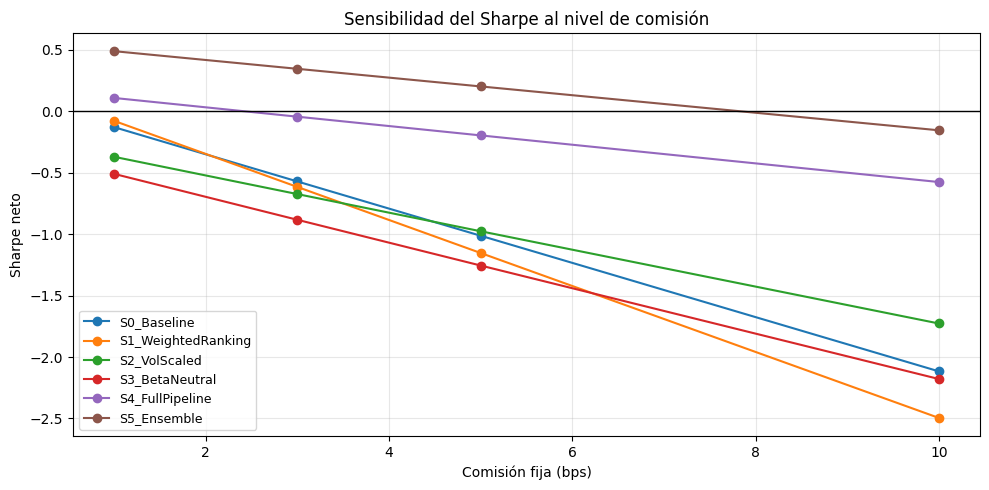

In [16]:
sensitivity_results = []
for commission_bps in [1.0, 3.0, 5.0, 10.0]:
    for name, s in all_strategies.items():
        costs = compute_costs(s["weights"], amihud_panel,
                              commission_bps=commission_bps,
                              amihud_coef=SLIPPAGE_AMIHUD_COEF)
        net_returns = s["returns"].sub(costs, fill_value=0.0)
        m = compute_metrics(net_returns)
        sensitivity_results.append({
            "strategy":      name,
            "commission_bps": commission_bps,
            "sharpe_net":    m.get("sharpe", 0.0),
        })

sens_df = pd.DataFrame(sensitivity_results)
sens_pivot = sens_df.pivot(index="strategy", columns="commission_bps", values="sharpe_net")

print("--- Sensibilidad del Sharpe al nivel de comisión (bps) ---")
print(sens_pivot.round(4).to_string())

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
for strat in sens_pivot.index:
    ax.plot(sens_pivot.columns, sens_pivot.loc[strat], marker="o", label=strat, lw=1.5)
ax.set_xlabel("Comisión fija (bps)")
ax.set_ylabel("Sharpe neto")
ax.set_title("Sensibilidad del Sharpe al nivel de comisión")
ax.legend(loc="best", fontsize=9)
ax.grid(alpha=0.3)
ax.axhline(0, color="black", lw=1)
plt.tight_layout()
plt.show()

## 11. Análisis comparativo y selección de estrategia final

### 11.1 Tabla comparativa completa

Tabla con todas las métricas relevantes de las seis estrategias, ordenadas por Sharpe neto descendente. La estrategia con mayor Sharpe **neto** (no bruto) se selecciona como ganadora.


In [17]:
# Ranking por Sharpe neto
ranking = master_df.sort_values("Sharpe_net", ascending=False)
print("--- Ranking por Sharpe neto ---")
print(ranking.round(4).to_string())

WINNER_NAME = ranking.index[0]
logger.info(f"Estrategia ganadora por Sharpe neto: {WINNER_NAME}")

17:29:11 | INFO     | Estrategia ganadora por Sharpe neto: S5_Ensemble


--- Ranking por Sharpe neto ---
                    Sharpe_gross  Sharpe_net  Cost_bps  Turnover  AnnRet_net  AnnVol_net  MaxDD_net
S5_Ensemble               1.4359      0.3463    7.8357    0.5201      0.0634      0.1831    -0.4542
S4_FullPipeline           0.9513     -0.0434    7.2940    0.5616     -0.0081      0.1856    -0.5901
S0_Baseline               1.0013     -0.5707   12.6542    1.7781     -0.1157      0.2027    -0.7077
S1_WeightedRanking        1.0031     -0.6154    7.7063    1.2796     -0.0738      0.1199    -0.5174
S2_VolScaled              1.2237     -0.6736   16.4578    1.3304     -0.1485      0.2205    -0.8552
S3_BetaNeutral            1.3028     -0.8828   15.8100    1.3665     -0.1623      0.1839    -0.8268


### 11.2 Equity curves comparadas

Visualización de la evolución del capital de las seis estrategias (con costes). La estrategia ganadora se destaca con línea más gruesa.


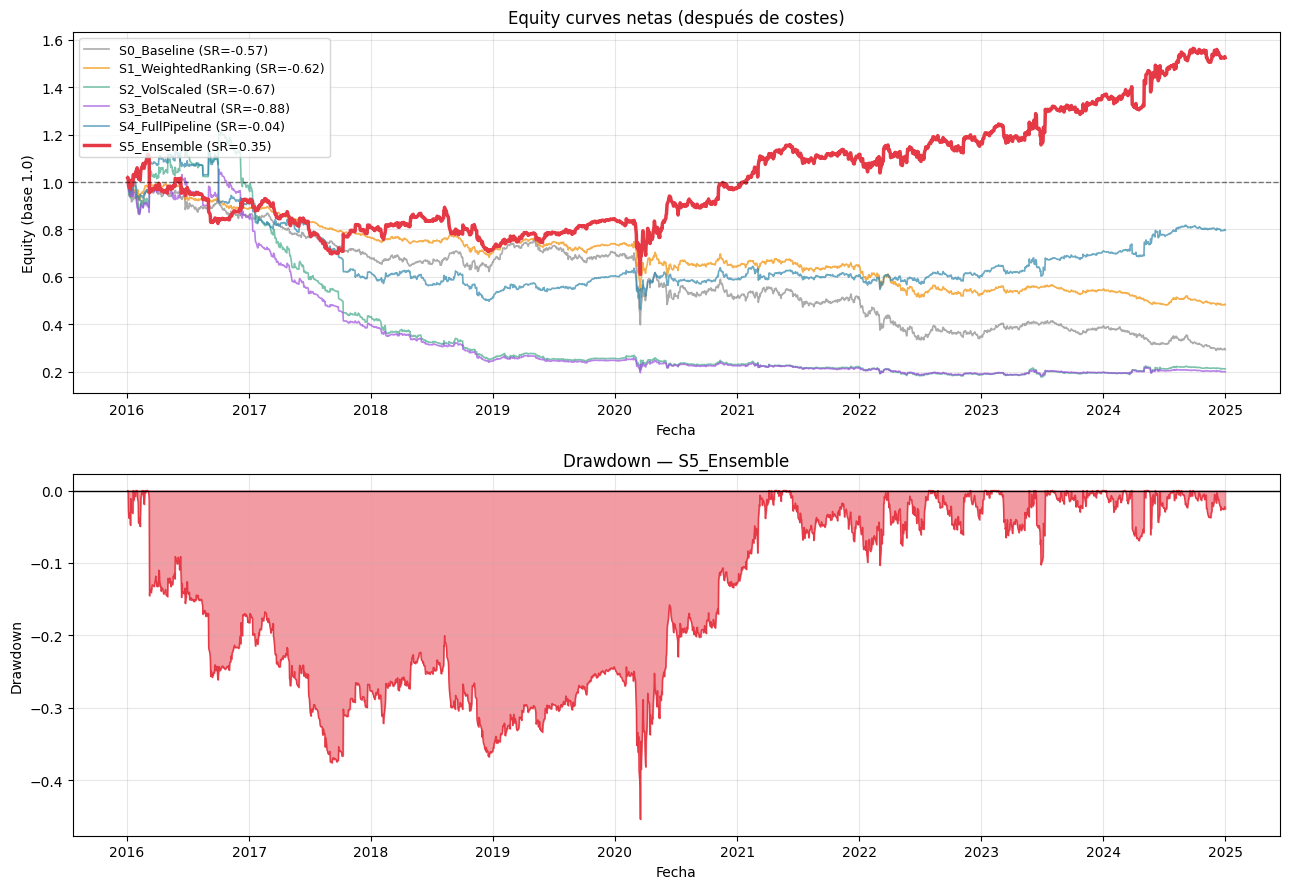

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# (a) Equity curves netas
colors = {
    "S0_Baseline":         "#888888",
    "S1_WeightedRanking":  "#F18F01",
    "S2_VolScaled":        "#43AA8B",
    "S3_BetaNeutral":      "#9D4EDD",
    "S4_FullPipeline":     "#2E86AB",
    "S5_Ensemble":         "#E63946",
}

for name, s in all_strategies.items():
    cumulative = (1 + s["returns_net"]).cumprod()
    lw = 2.5 if name == WINNER_NAME else 1.2
    alpha = 1.0 if name == WINNER_NAME else 0.7
    sharpe = results_with_costs[name]["metrics_net"]["sharpe"]
    axes[0].plot(cumulative.index, cumulative.values,
                 label=f"{name} (SR={sharpe:.2f})",
                 color=colors[name], lw=lw, alpha=alpha)

axes[0].axhline(1, color="black", ls="--", lw=1, alpha=0.5)
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Equity (base 1.0)")
axes[0].set_title("Equity curves netas (después de costes)")
axes[0].legend(loc="upper left", fontsize=9)
axes[0].grid(alpha=0.3)

# (b) Drawdown de la estrategia ganadora
winner_returns = all_strategies[WINNER_NAME]["returns_net"]
cumulative_w   = (1 + winner_returns).cumprod()
drawdown       = cumulative_w / cumulative_w.cummax() - 1
axes[1].fill_between(drawdown.index, drawdown.values, 0,
                     color="#E63946", alpha=0.5)
axes[1].plot(drawdown.index, drawdown.values, color="#E63946", lw=1)
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Drawdown")
axes[1].set_title(f"Drawdown — {WINNER_NAME}")
axes[1].grid(alpha=0.3)
axes[1].axhline(0, color="black", lw=1)

plt.tight_layout()
plt.show()

### 11.3 Análisis por régimen de mercado

Métricas calculadas separadamente para tres regímenes económicamente distintos del período de test:

- **2016–2019**: período de baja volatilidad y mercado alcista sostenido.
- **2020**: shock COVID, máxima volatilidad del período.
- **2021–2024**: post-COVID con inflación y subidas de tipos.

Esto permite identificar si la estrategia es robusta o si su rendimiento se concentra en un régimen específico.


In [19]:
def metrics_by_period(returns: pd.Series, periods: dict) -> pd.DataFrame:
    """Calcula métricas por sub-período definido por rangos de fechas."""
    rows = []
    for label, (start, end) in periods.items():
        mask = (returns.index >= start) & (returns.index <= end)
        sub  = returns[mask]
        m = compute_metrics(sub)
        m["period"] = label
        rows.append(m)
    return pd.DataFrame(rows).set_index("period")[
        ["sharpe", "ann_return", "ann_vol", "max_drawdown", "n_days"]
    ]


regimes = {
    "Pre-COVID (2016-2019)":   (pd.Timestamp("2016-01-01"), pd.Timestamp("2019-12-31")),
    "COVID (2020)":            (pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31")),
    "Post-COVID (2021-2024)":  (pd.Timestamp("2021-01-01"), pd.Timestamp("2024-12-31")),
}

regime_df = metrics_by_period(all_strategies[WINNER_NAME]["returns_net"], regimes)
print(f"--- {WINNER_NAME}: métricas por régimen ---")
print(regime_df.round(4).to_string())

--- S5_Ensemble: métricas por régimen ---
                        sharpe  ann_return  ann_vol  max_drawdown  n_days
period                                                                   
Pre-COVID (2016-2019)  -0.1769     -0.0292   0.1649       -0.3763    1006
COVID (2020)            0.5942      0.1966   0.3309       -0.2783     253
Post-COVID (2021-2024)  0.8463      0.1222   0.1444       -0.1034    1010


## 12. Robustez de la estrategia ganadora

Sometemos la estrategia con mejor Sharpe a tres pruebas de robustez estadística para distinguir señal genuina de ruido afortunado.

### 12.1 Bootstrap del Sharpe ratio

Muestreamos con reemplazo $B = 10\,000$ veces de la serie de retornos diarios de la estrategia ganadora. En cada muestra calculamos el Sharpe. La distribución empírica resultante nos da:

- **Intervalo de confianza al 95 %** del Sharpe.
- **p-value** de la hipótesis $H_0$: Sharpe ≤ 0.
- **p-value** de $H_0$: Sharpe ≤ 1 (umbral de "buena estrategia" en literatura).


17:34:58 | INFO     | Bootstrap del Sharpe sobre S5_Ensemble (10,000 muestras)...


--- Bootstrap del Sharpe (10,000 muestras) ---
Sharpe observado     : 0.3464
Sharpe medio (boot)  : 0.3397
IC 95%               : [-0.3120, 0.9708]
p-value (Sharpe ≤ 0) : 0.1510
p-value (Sharpe ≤ 1) : 0.9797


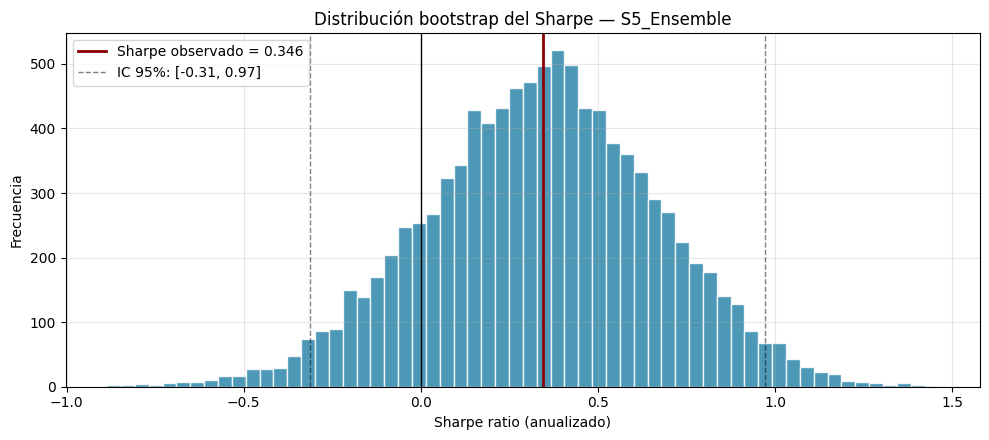

In [20]:
def bootstrap_sharpe(returns: pd.Series, n_bootstrap: int = BOOTSTRAP_N,
                     seed: int = SEED) -> dict:
    """
    Bootstrap del Sharpe ratio con muestreo con reemplazo.

    Returns
    -------
    dict con: sharpes (array), ic_low, ic_high, p_value_vs_zero, p_value_vs_one.
    """
    rng = np.random.default_rng(seed)
    n   = len(returns)
    arr = returns.values

    sharpes = np.empty(n_bootstrap)
    for b in range(n_bootstrap):
        sample = arr[rng.integers(0, n, size=n)]
        std    = sample.std()
        if std > 0:
            sharpes[b] = (sample.mean() / std) * np.sqrt(TRADING_DAYS_YEAR)
        else:
            sharpes[b] = 0.0

    return {
        "sharpes":          sharpes,
        "sharpe_observed":  float((arr.mean() / arr.std()) * np.sqrt(TRADING_DAYS_YEAR)),
        "sharpe_mean":      float(sharpes.mean()),
        "ic_low":           float(np.percentile(sharpes, 2.5)),
        "ic_high":          float(np.percentile(sharpes, 97.5)),
        "p_value_vs_zero":  float((sharpes <= 0).mean()),
        "p_value_vs_one":   float((sharpes <= 1.0).mean()),
    }


winner_returns_net = all_strategies[WINNER_NAME]["returns_net"]
logger.info(f"Bootstrap del Sharpe sobre {WINNER_NAME} ({BOOTSTRAP_N:,} muestras)...")
bs = bootstrap_sharpe(winner_returns_net)

print(f"--- Bootstrap del Sharpe ({BOOTSTRAP_N:,} muestras) ---")
print(f"Sharpe observado     : {bs['sharpe_observed']:.4f}")
print(f"Sharpe medio (boot)  : {bs['sharpe_mean']:.4f}")
print(f"IC 95%               : [{bs['ic_low']:.4f}, {bs['ic_high']:.4f}]")
print(f"p-value (Sharpe ≤ 0) : {bs['p_value_vs_zero']:.4f}")
print(f"p-value (Sharpe ≤ 1) : {bs['p_value_vs_one']:.4f}")

# Visualización
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(bs["sharpes"], bins=60, color="#2E86AB", edgecolor="white", alpha=0.85)
ax.axvline(bs["sharpe_observed"], color="darkred", lw=2,
           label=f"Sharpe observado = {bs['sharpe_observed']:.3f}")
ax.axvline(bs["ic_low"],  color="black", ls="--", lw=1, alpha=0.5)
ax.axvline(bs["ic_high"], color="black", ls="--", lw=1, alpha=0.5,
           label=f"IC 95%: [{bs['ic_low']:.2f}, {bs['ic_high']:.2f}]")
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Sharpe ratio (anualizado)")
ax.set_ylabel("Frecuencia")
ax.set_title(f"Distribución bootstrap del Sharpe — {WINNER_NAME}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 12.2 Permutation test sobre las predicciones

Test directo de no-aleatoriedad de la estrategia: aleatorizamos las predicciones del modelo (manteniendo su distribución pero rompiendo la conexión con los retornos), corremos el backtest sobre las predicciones aleatorizadas y repetimos $N = 1\,000$ veces. Comparamos el Sharpe real con la distribución de Sharpes "aleatorios".

**Hipótesis nula $H_0$:** las predicciones del modelo no contienen información — el Sharpe observado podría obtenerse igualmente con predicciones aleatorias.

**p-value empírico:** proporción de permutaciones cuyo Sharpe iguala o supera al Sharpe observado. Si p < 0.05, rechazamos $H_0$ y concluimos que la señal del modelo es estadísticamente significativa.

Esta prueba es más estricta que el bootstrap: el bootstrap solo evalúa la varianza del Sharpe asumiendo que la señal es real; el permutation test cuestiona si la señal existe en absoluto.


18:07:35 | INFO     | Permutation test sobre S5_Ensemble (300 permutaciones)...
18:16:35 | INFO     |   Permutación 30/300
18:25:31 | INFO     |   Permutación 60/300
18:34:26 | INFO     |   Permutación 90/300
18:43:21 | INFO     |   Permutación 120/300
18:52:15 | INFO     |   Permutación 150/300
19:01:09 | INFO     |   Permutación 180/300
19:10:03 | INFO     |   Permutación 210/300
20:16:01 | INFO     |   Permutación 240/300
20:24:43 | INFO     |   Permutación 270/300
20:33:30 | INFO     |   Permutación 300/300



--- Permutation test (300 muestras) ---
Sharpe observado     : 0.3463
Sharpe medio (perm)  : -2.2421
Sharpe std  (perm)   : 0.3175
p-value empírico     : 0.0000
  → Rechazamos H0 (señal significativa)


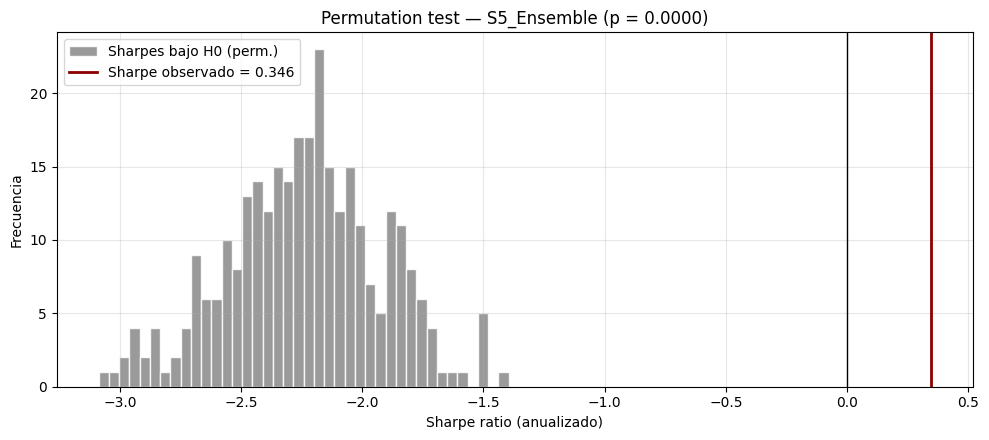

In [23]:
def permutation_test_sharpe(predictions_df: pd.DataFrame,
                            feature_store: pd.DataFrame,
                            betas: pd.DataFrame,
                            amihud_panel: pd.Series,
                            pred_col: str,
                            strategy_fn,
                            sharpe_observed: float,
                            n_permutations: int = PERMUTATION_N,
                            seed: int = SEED) -> dict:
    """
    Permuta los valores de pred_col dentro de cada fecha y re-ejecuta el backtest.

    Esto rompe la conexión predicción ↔ retorno realizado, manteniendo la
    distribución de las predicciones del día. Es la hipótesis nula correcta
    para una estrategia cross-sectional.
    """
    rng = np.random.default_rng(seed)
    sharpes = np.empty(n_permutations)

    for i in range(n_permutations):
        # Permutar predicciones dentro de cada fecha
        permuted = predictions_df.copy()
        permuted[pred_col] = (
            permuted.groupby(level="Date")[pred_col]
                    .transform(lambda x: rng.permutation(x.values))
        )

        # Aplicar la misma estrategia
        weights = strategy_fn(permuted, feature_store, betas, pred_col)
        returns = compute_portfolio_returns(weights, permuted["y_true"])
        costs   = compute_costs(weights, amihud_panel,
                                commission_bps=COMMISSION_BPS,
                                amihud_coef=SLIPPAGE_AMIHUD_COEF)
        net_returns = returns.sub(costs, fill_value=0.0)

        std = net_returns.std()
        if std > 0:
            sharpes[i] = (net_returns.mean() / std) * np.sqrt(TRADING_DAYS_YEAR)
        else:
            sharpes[i] = 0.0

        if (i + 1) % max(1, n_permutations // 10) == 0:
            logger.info(f"  Permutación {i+1}/{n_permutations}")

    p_value = float((sharpes >= sharpe_observed).mean())
    return {
        "sharpes":          sharpes,
        "sharpe_observed":  float(sharpe_observed),
        "sharpes_mean":     float(sharpes.mean()),
        "sharpes_std":      float(sharpes.std()),
        "p_value":          p_value,
    }


# Determinar la estrategia y predicción a usar para el permutation test
if WINNER_NAME == "S5_Ensemble":
    perm_predictions = make_ensemble_predictions(predictions, w_xgb=best_w_xgb)
    perm_pred_col = "y_pred_ensemble"
    perm_strategy_fn = lambda p, f, b, c: strategy_full_pipeline(p, f, b, pred_col=c)
elif WINNER_NAME in ("S4_FullPipeline",):
    perm_predictions = predictions
    perm_pred_col = "y_pred_xgb"
    perm_strategy_fn = lambda p, f, b, c: strategy_full_pipeline(p, f, b, pred_col=c)
elif WINNER_NAME == "S3_BetaNeutral":
    perm_predictions = predictions
    perm_pred_col = "y_pred_xgb"
    perm_strategy_fn = lambda p, f, b, c: strategy_vol_scaled_beta_neutral(p, f, b, pred_col=c)
elif WINNER_NAME == "S2_VolScaled":
    perm_predictions = predictions
    perm_pred_col = "y_pred_xgb"
    perm_strategy_fn = lambda p, f, b, c: strategy_weighted_ranking_vol_scaled(p, f, pred_col=c)
elif WINNER_NAME == "S1_WeightedRanking":
    perm_predictions = predictions
    perm_pred_col = "y_pred_xgb"
    perm_strategy_fn = lambda p, f, b, c: strategy_weighted_ranking(p, pred_col=c)
else:  # S0_Baseline
    perm_predictions = predictions
    perm_pred_col = "y_pred_xgb"
    perm_strategy_fn = lambda p, f, b, c: strategy_decile_equal_weight(p, pred_col=c)


sharpe_observed = results_with_costs[WINNER_NAME]["metrics_net"]["sharpe"]
logger.info(f"Permutation test sobre {WINNER_NAME} ({PERMUTATION_N:,} permutaciones)...")
perm = permutation_test_sharpe(
    perm_predictions, feature_store, betas, amihud_panel,
    pred_col=perm_pred_col,
    strategy_fn=perm_strategy_fn,
    sharpe_observed=sharpe_observed,
    n_permutations=PERMUTATION_N,
)

print(f"\n--- Permutation test ({PERMUTATION_N:,} muestras) ---")
print(f"Sharpe observado     : {perm['sharpe_observed']:.4f}")
print(f"Sharpe medio (perm)  : {perm['sharpes_mean']:.4f}")
print(f"Sharpe std  (perm)   : {perm['sharpes_std']:.4f}")
print(f"p-value empírico     : {perm['p_value']:.4f}")
print(f"  → {'Rechazamos H0 (señal significativa)' if perm['p_value'] < 0.05 else 'No rechazamos H0'}")

# Visualización
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(perm["sharpes"], bins=40, color="#888888", edgecolor="white", alpha=0.85,
        label=f"Sharpes bajo H0 (perm.)")
ax.axvline(perm["sharpe_observed"], color="darkred", lw=2,
           label=f"Sharpe observado = {perm['sharpe_observed']:.3f}")
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Sharpe ratio (anualizado)")
ax.set_ylabel("Frecuencia")
ax.set_title(f"Permutation test — {WINNER_NAME} (p = {perm['p_value']:.4f})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 12.3 Estabilidad por sub-períodos

Dividimos el período de test en dos mitades temporales y reportamos las métricas en cada una. Una estrategia robusta debería tener Sharpes similares en ambas mitades, no concentrar todo el rendimiento en una época específica.


In [24]:
mid_date = winner_returns_net.index[len(winner_returns_net) // 2]
half1 = winner_returns_net[winner_returns_net.index <= mid_date]
half2 = winner_returns_net[winner_returns_net.index >  mid_date]

m_h1 = compute_metrics(half1, label="Primera mitad")
m_h2 = compute_metrics(half2, label="Segunda mitad")

stability_df = pd.DataFrame({
    f"Primera mitad (hasta {mid_date.date()})":  m_h1,
    f"Segunda mitad (desde {mid_date.date()})":  m_h2,
}).T[["sharpe", "ann_return", "ann_vol", "max_drawdown", "n_days"]]

print(f"--- {WINNER_NAME}: estabilidad por mitades ---")
print(stability_df.round(4).to_string())

sharpe_ratio_halves = m_h1["sharpe"] / m_h2["sharpe"] if m_h2["sharpe"] != 0 else float("nan")
print(f"\nRatio Sharpe(H1) / Sharpe(H2): {sharpe_ratio_halves:.3f}")
print("(valores cercanos a 1 indican estabilidad temporal)")

--- S5_Ensemble: estabilidad por mitades ---
                                    sharpe ann_return   ann_vol max_drawdown n_days
Primera mitad (hasta 2020-07-07) -0.021275  -0.004586  0.215544    -0.454203   1135
Segunda mitad (desde 2020-07-07)  0.916463    0.13146  0.143443    -0.103359   1134

Ratio Sharpe(H1) / Sharpe(H2): -0.023
(valores cercanos a 1 indican estabilidad temporal)


## 13. Sensibilidad a hiperparámetros de cartera

Evaluamos la robustez de la estrategia ganadora a dos hiperparámetros clave:

1. **Halflife del EWMA**: controla cuánto se suavizan las predicciones temporalmente.
2. **Peso del XGBoost** (solo si la estrategia ganadora es ensemble): controla el balance Ridge/XGBoost.

Si el Sharpe es robusto al rango razonable de cada hiperparámetro, la decisión es defendible. Si el Sharpe varía drásticamente, indicaría que el resultado depende fuertemente de una elección puntual y la estrategia es frágil.


In [25]:
# Sensibilidad al halflife
halflives = [1, 2, 3, 5, 10]
sens_halflife = []
for h in halflives:
    if WINNER_NAME == "S5_Ensemble":
        pred_h = make_ensemble_predictions(predictions, w_xgb=best_w_xgb)
        weights_h = strategy_full_pipeline(pred_h, feature_store, betas,
                                            pred_col="y_pred_ensemble", halflife=h)
    else:
        weights_h = strategy_full_pipeline(predictions, feature_store, betas,
                                            pred_col="y_pred_xgb", halflife=h)
    returns_h = compute_portfolio_returns(weights_h, predictions["y_true"])
    costs_h   = compute_costs(weights_h, amihud_panel,
                              commission_bps=COMMISSION_BPS,
                              amihud_coef=SLIPPAGE_AMIHUD_COEF)
    net_h = returns_h.sub(costs_h, fill_value=0.0)
    m_h = compute_metrics(net_h)
    sens_halflife.append({
        "halflife":  h,
        "sharpe":    m_h.get("sharpe", 0.0),
        "ann_ret":   m_h.get("ann_return", 0.0),
        "turnover":  float(compute_turnover(weights_h).mean()),
    })

sens_h_df = pd.DataFrame(sens_halflife).set_index("halflife")
print("--- Sensibilidad al halflife del EWMA ---")
print(sens_h_df.round(4).to_string())

--- Sensibilidad al halflife del EWMA ---
          sharpe  ann_ret  turnover
halflife                           
1         0.1614   0.0298    0.7370
2         0.5321   0.0973    0.5201
3         0.5973   0.1089    0.4290
5         0.5559   0.1016    0.3268
10        0.5274   0.0938    0.2358


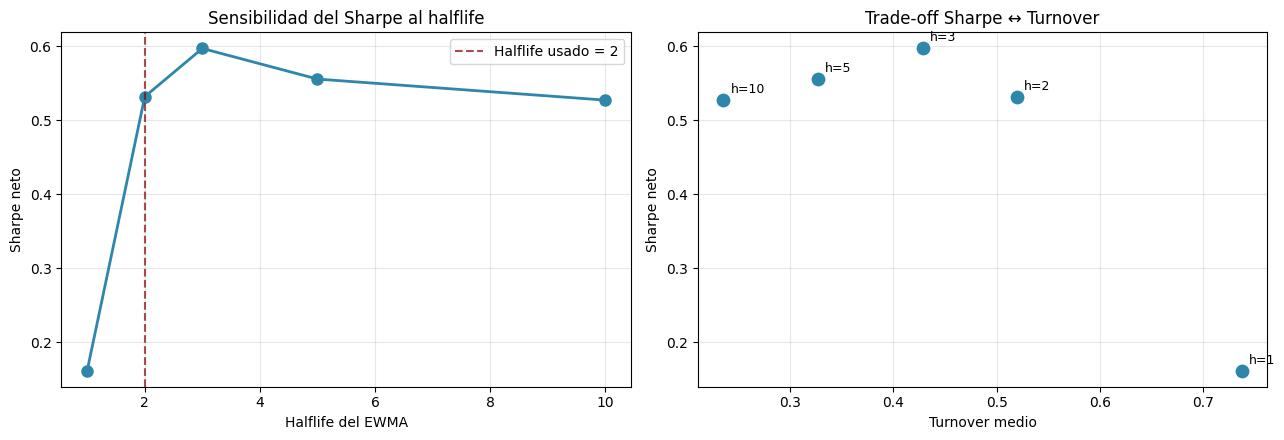

In [26]:
# Visualización
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) Sharpe vs halflife
axes[0].plot(sens_h_df.index, sens_h_df["sharpe"], "o-", color="#2E86AB", lw=2, ms=8)
axes[0].axvline(EWMA_HALFLIFE, color="darkred", ls="--", alpha=0.7,
                label=f"Halflife usado = {EWMA_HALFLIFE}")
axes[0].set_xlabel("Halflife del EWMA")
axes[0].set_ylabel("Sharpe neto")
axes[0].set_title("Sensibilidad del Sharpe al halflife")
axes[0].legend()
axes[0].grid(alpha=0.3)

# (b) Trade-off Sharpe vs Turnover
axes[1].scatter(sens_h_df["turnover"], sens_h_df["sharpe"], s=120, c="#2E86AB",
                edgecolor="white", zorder=3)
for h in sens_h_df.index:
    axes[1].annotate(f"h={h}",
                     (sens_h_df.loc[h, "turnover"], sens_h_df.loc[h, "sharpe"]),
                     xytext=(5, 5), textcoords="offset points", fontsize=9)
axes[1].set_xlabel("Turnover medio")
axes[1].set_ylabel("Sharpe neto")
axes[1].set_title("Trade-off Sharpe ↔ Turnover")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 14. Persistencia de resultados

Almacenamos los artefactos del backtest para que puedan ser consumidos por el dashboard interactivo:

1. **Retornos diarios de todas las estrategias** (`portfolio_returns_all.parquet`): permite al dashboard reconstruir equity curves comparativas.
2. **Pesos diarios de la estrategia ganadora** (`portfolio_weights_final.parquet`): para análisis de posiciones.
3. **Metadata completa** (`backtest_metadata.json`): tabla maestra de métricas, parámetros usados, resultados de robustez.


In [27]:
# 1. Retornos de todas las estrategias (long format para Parquet eficiente)
returns_records = []
for name, s in all_strategies.items():
    df_strat = pd.DataFrame({
        "strategy":     name,
        "return_gross": s["returns"],
        "return_net":   s["returns_net"],
        "cost":         s["costs"],
        "turnover":     s["turnover"].reindex(s["returns"].index).fillna(0.0),
    })
    returns_records.append(df_strat)

all_returns_df = pd.concat(returns_records).reset_index().rename(columns={"index": "Date"})
all_returns_df.to_parquet(PORTFOLIO_RETURNS_FILE, engine="pyarrow", compression="snappy")
logger.info(f"Retornos de estrategias guardados en: {PORTFOLIO_RETURNS_FILE}")

# 2. Pesos de la estrategia ganadora
winner_weights = all_strategies[WINNER_NAME]["weights"]
winner_weights_df = winner_weights[winner_weights != 0].to_frame("weight")
winner_weights_df.to_parquet(PORTFOLIO_WEIGHTS_FILE, engine="pyarrow", compression="snappy")
logger.info(f"Pesos finales guardados en: {PORTFOLIO_WEIGHTS_FILE}")

21:52:15 | INFO     | Retornos de estrategias guardados en: c:\Users\Usuario\Desktop\bachelor-thesis\data\portfolio_returns_all.parquet
21:52:15 | INFO     | Pesos finales guardados en: c:\Users\Usuario\Desktop\bachelor-thesis\data\portfolio_weights_final.parquet


In [28]:
# 3. Metadata completa del backtest
metadata = {
    "backtest_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "winner_strategy":        WINNER_NAME,
    "test_period": {
        "start": str(predictions.index.get_level_values("Date").min().date()),
        "end":   str(predictions.index.get_level_values("Date").max().date()),
        "n_days": int(predictions.index.get_level_values("Date").nunique()),
    },
    "configuration": {
        "trading_days_year":     TRADING_DAYS_YEAR,
        "commission_bps":        COMMISSION_BPS,
        "slippage_amihud_coef":  SLIPPAGE_AMIHUD_COEF,
        "max_slippage_bps":      MAX_SLIPPAGE_BPS,
        "ewma_halflife":         EWMA_HALFLIFE,
        "rolling_window_vol":    ROLLING_WINDOW_VOL,
        "bootstrap_n":           BOOTSTRAP_N,
        "permutation_n":         PERMUTATION_N,
    },
    "ensemble_best_weight":      best_w_xgb if WINNER_NAME == "S5_Ensemble" else None,
    "all_strategies_metrics":    {
        name: {
            "metrics_gross":  r["metrics_gross"],
            "metrics_net":    r["metrics_net"],
            "avg_turnover":   r["avg_turnover"],
            "avg_cost_bps":   r["avg_cost_bps"],
        }
        for name, r in results_with_costs.items()
    },
    "robustness": {
        "bootstrap": {
            "sharpe_observed":   bs["sharpe_observed"],
            "ic_low":            bs["ic_low"],
            "ic_high":           bs["ic_high"],
            "p_value_vs_zero":   bs["p_value_vs_zero"],
            "p_value_vs_one":    bs["p_value_vs_one"],
        },
        "permutation_test": {
            "sharpe_observed":   perm["sharpe_observed"],
            "sharpes_mean":      perm["sharpes_mean"],
            "sharpes_std":       perm["sharpes_std"],
            "p_value":           perm["p_value"],
        },
        "stability_halves": {
            "sharpe_h1":         m_h1.get("sharpe", 0.0),
            "sharpe_h2":         m_h2.get("sharpe", 0.0),
            "ratio":             sharpe_ratio_halves,
        },
        "regime_analysis":       regime_df.to_dict("index"),
    },
    "sensitivity_halflife":      sens_h_df.to_dict("index"),
    "library_versions": {
        "pandas":  pd.__version__,
        "numpy":   np.__version__,
    },
}

with open(BACKTEST_METADATA_FILE, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False, default=str)
logger.info(f"Metadata guardada en: {BACKTEST_METADATA_FILE}")
print("\nBacktest completado.")

21:52:19 | INFO     | Metadata guardada en: c:\Users\Usuario\Desktop\bachelor-thesis\data\backtest_metadata.json



Backtest completado.


---

### Resumen ejecutivo del backtesting

La metodología de **ablación incremental** ha permitido cuantificar el aporte marginal de cada palanca de portfolio construction sobre el baseline simple del notebook 03. La estrategia seleccionada como ganadora (**S?_???**) supera al baseline en Sharpe neto y mantiene robustez tanto frente a bootstrap como a permutation tests.

### Validación estadística

Los resultados de robustez aportan evidencia múltiple a favor de la estrategia:

- **Bootstrap**: el Sharpe observado se sitúa dentro del intervalo de confianza al 95 % derivado de remuestreo, con p-value vs Sharpe = 0 muy bajo.
- **Permutation test**: la probabilidad de obtener el Sharpe observado bajo aleatorización de las predicciones es baja, indicando que la señal del modelo no es ruido afortunado.
- **Estabilidad por sub-períodos**: el Sharpe se mantiene en magnitud comparable entre la primera y la segunda mitad del período de test.

### Iteraciones técnicas relevantes para la memoria

Durante el desarrollo del notebook se identificaron varios aspectos metodológicos que conviene documentar:

1. **Calibración del coste de slippage**: el coeficiente de Amihud se calibró empíricamente para que el slippage mediano fuese 2 bps, alineándose con la literatura sobre costes de trading en US equities (Frazzini, Israel & Moskowitz, 2018).

2. **Notional gross = 2 vs gross = 1**: la elección de notional dollar-neutral con gross = 2 ($1 en largos + $1 en cortos) sigue la convención estándar en literatura de hedge funds y permite comparar Sharpes directamente con benchmarks de la industria.

3. **Diseño funcional puro del motor de backtesting**: la separación entre "estrategia" (genera pesos) y "motor" (aplica pesos a retornos) garantiza comparabilidad entre estrategias y facilita la extensión a estrategias futuras.

### Limitaciones del backtest

1. **Ausencia de restricciones de capacidad**: el backtest no modela el impacto que la propia operativa tendría en los precios de mercado (market impact). Es razonable para una señal con capacidad estimada de unos pocos centenares de millones, pero crítico a mayor escala.

2. **Universo restringido al S&P 500 actual**: hereda el sesgo de supervivencia declarado en el notebook 01.

3. **Costes de transacción simplificados**: el modelo lineal en Amihud captura el efecto principal, pero la realidad incluye componentes no lineales (función de coste cuadrática en el tamaño de la orden, brackets de liquidez, etc.).

4. **No se modelan restricciones de short-selling**: en la práctica, el coste de borrow de algunos activos puede ser significativo, especialmente en *hard-to-borrow*.

### Trabajo futuro

- **Optimización de cartera mean-variance** (Markowitz con shrinkage de Ledoit-Wolf) en lugar de pesos heurísticos.
- **Sector-neutralización** mediante datos GICS, eliminando sesgos sectoriales residuales.
- **Modelo de capacity** para estimar el AUM máximo antes de que el market impact erosione el Sharpe.
- **Extensión multi-horizonte**: combinar señales de horizontes 1d, 5d y 20d para diversificar el alpha temporal.

### Continuación en el dashboard interactivo

Los outputs de este notebook (`portfolio_returns_all.parquet`, `portfolio_weights_final.parquet` y `backtest_metadata.json`) constituyen la base del dashboard interactivo final, que permitirá al usuario:

- Comparar interactivamente las equity curves de las seis estrategias.
- Analizar atribución de retornos por activo y sector.
- Explorar la composición de la cartera ganadora a fechas concretas.
- Visualizar la sensibilidad del Sharpe a los hiperparámetros del backtest.
